# **Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# **Upload Dataset**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (7043, 21)


# **Initial Dataset Inspection**

In [4]:
print("First five records:")
display(df.head())

First five records:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Last five records:")
display(df.tail())

Last five records:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
print("Dataset dimensions:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset dimensions:
Rows: 7043
Columns: 21


In [7]:
print("Column names:")
print(df.columns.tolist())

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


# **Data Types and Structure**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Check Missing Values**

In [10]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

display(
    missing_table[
        missing_table["Missing Values"] > 0
    ].sort_values(
        by="Missing Values",
        ascending=False
    )
)

,Missing Values,Percentage


In [11]:
blank_values = (df == "").sum()

display(
    blank_values[blank_values > 0]
)

,0


In [12]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


# **Check Target Variable**

In [13]:
print("Unique Churn values:")
print(df["Churn"].unique())

Unique Churn values:
['No' 'Yes']


In [14]:
churn_counts = df["Churn"].value_counts()

display(churn_counts)

,count
Churn,
No,5174
Yes,1869


In [15]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

display(churn_percentage)

,proportion
Churn,
No,73.463013
Yes,26.536987


# **Churn Distribution Visualisation**

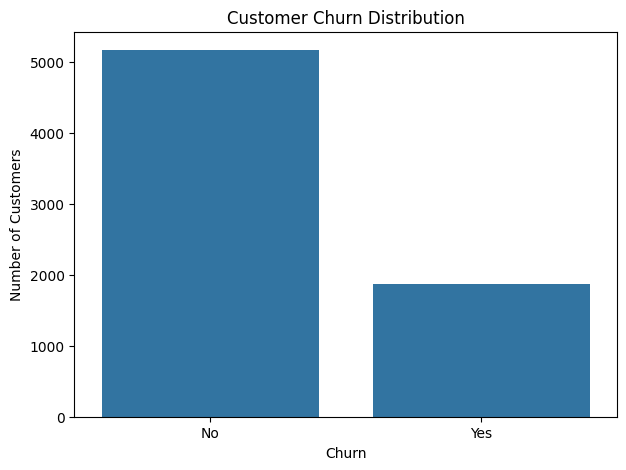

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

# **Data Cleaning: TotalCharges**

In [17]:
print(df["TotalCharges"].dtype)

object


In [18]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].dtype)

float64


In [19]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

print(
    "Missing TotalCharges after treatment:",
    df["TotalCharges"].isnull().sum()
)

Missing TotalCharges after treatment: 0


# **Customer ID Check**

In [20]:
df = df.drop(columns=["customerID"])

print("customerID removed.")
print("New dataset shape:", df.shape)

customerID removed.
New dataset shape: (7043, 20)


# **Final Data Quality Check**

In [21]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate records:")
print(df.duplicated().sum())

print("\nDataset shape:")
print(df.shape)

Missing values:


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0



Duplicate records:
22

Dataset shape:
(7043, 20)


In [22]:
duplicate_rows = df[df.duplicated(keep=False)].copy()

print("Number of duplicated rows:", len(duplicate_rows))

display(
    duplicate_rows.sort_values(
        by=list(df.columns)
    ).head(50)
)

Number of duplicated rows: 42


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6491,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
6764,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
4495,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
6267,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
5522,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
5759,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No


In [23]:
duplicate_groups = df[df.duplicated(keep=False)].value_counts()

print("Number of duplicate groups:", len(duplicate_groups))

Number of duplicate groups: 20


In [24]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicate records:", df.duplicated().sum())

Dataset shape after removing duplicates: (7021, 20)
Remaining duplicate records: 0


# **Exploratory Data Analysis**

## **Churn by Contract**

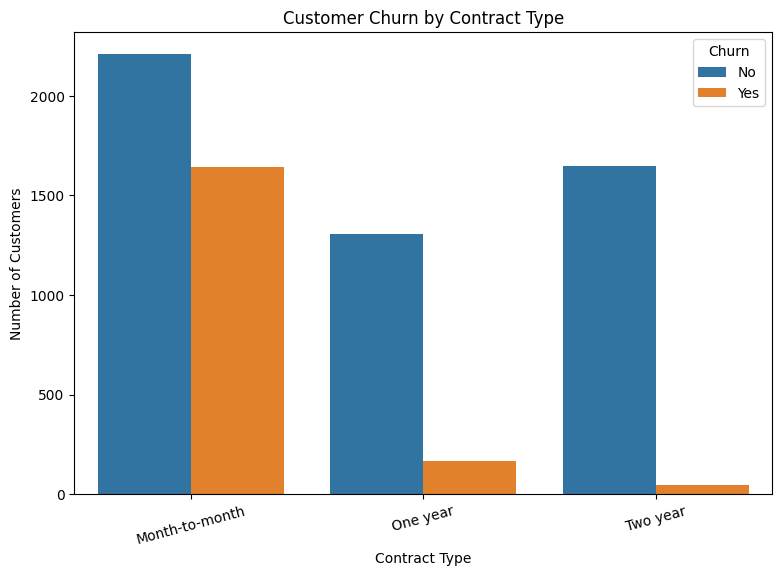

In [25]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

## **Churn Rate by Contract**

Churn,No,Yes
Contract,,
Month-to-month,57.357903,42.642097
One year,88.730482,11.269518
Two year,97.168142,2.831858


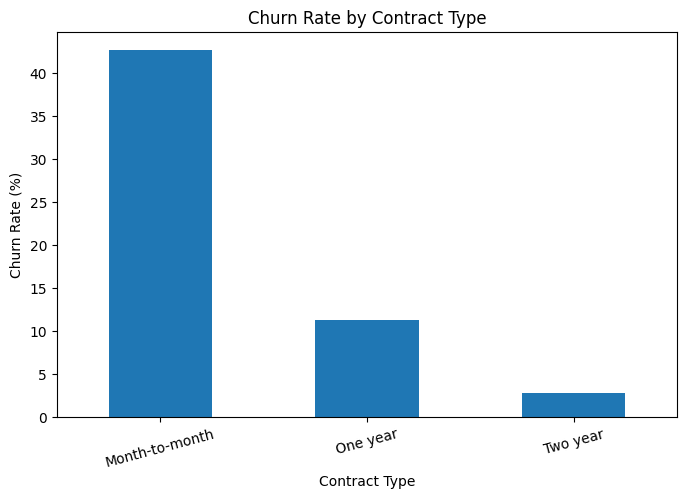

In [27]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

display(contract_churn)

contract_churn["Yes"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=15)

plt.show()

## **Churn and Tenure**

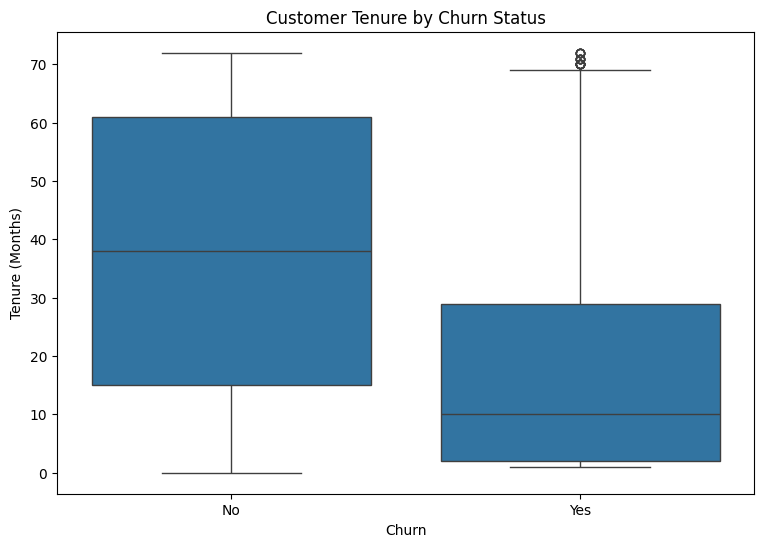

In [28]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

## **Monthly Charges and Churn**

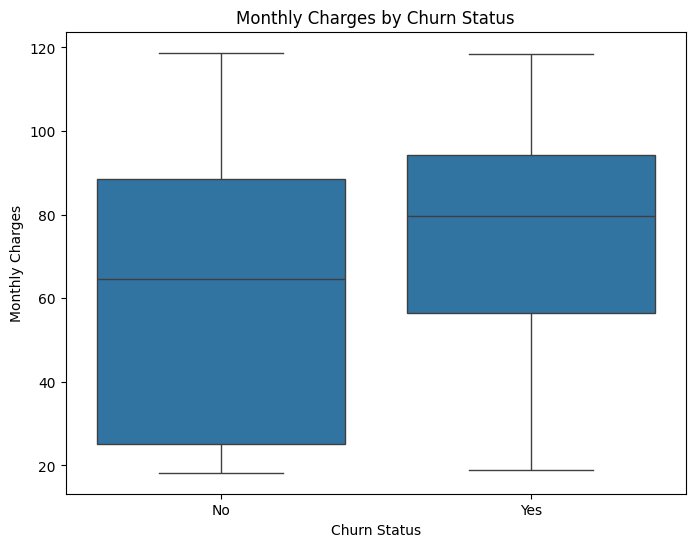

In [29]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.show()

## **Internet Service and Churn**

Churn Rate by Internet Service:


Churn,No,Yes
InternetService,,
DSL,81.11,18.89
Fiber optic,58.22,41.78
No,92.79,7.21


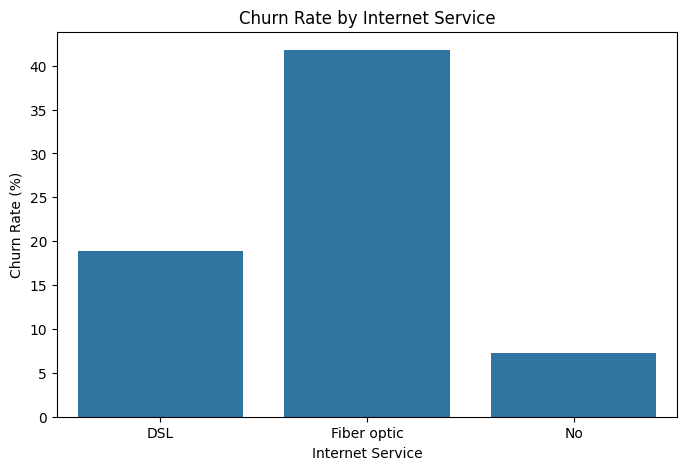

In [30]:
internet_churn_rate = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn Rate by Internet Service:")
display(internet_churn_rate.round(2))


plt.figure(figsize=(8, 5))

sns.barplot(
    x=internet_churn_rate.index,
    y=internet_churn_rate["Yes"]
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.show()

## **Payment Method and Churn**

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.853752,45.146248
Mailed check,81.077694,18.922306


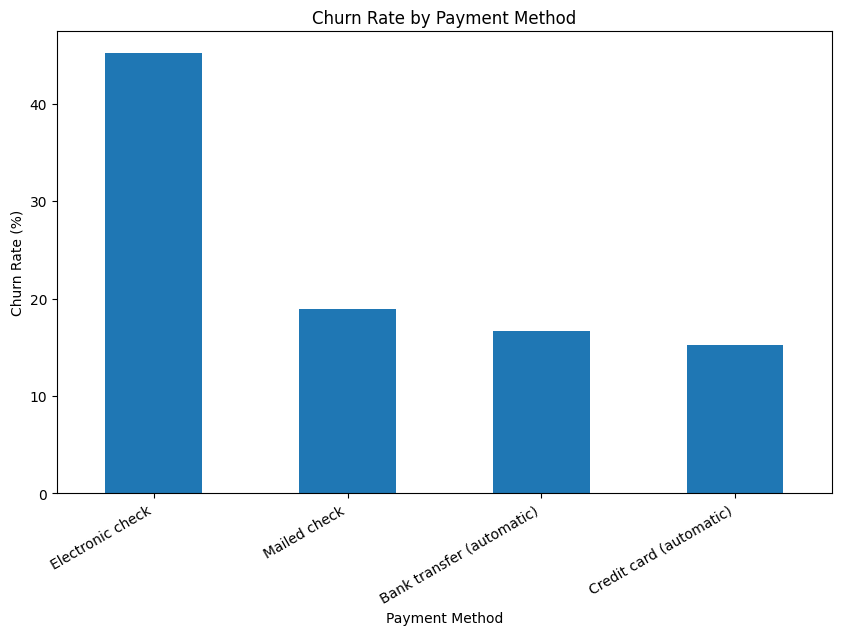

In [31]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

display(payment_churn)

payment_churn["Yes"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30, ha="right")

plt.show()

## **Churn by Technical Support**

Churn,No,Yes
TechSupport,,
No,58.499278,41.500722
No internet service,92.791005,7.208995
Yes,84.833659,15.166341


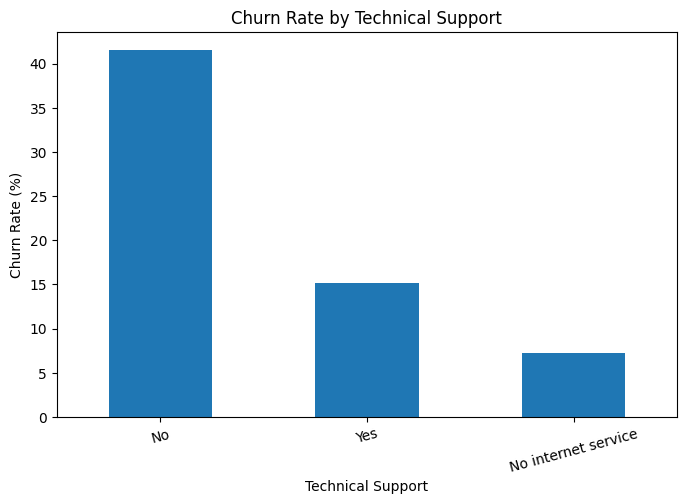

In [32]:
support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

display(support_churn)

support_churn["Yes"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=15)

plt.show()

## **Churn by Online Security**

In [33]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

display(security_churn)

Churn,No,Yes
OnlineSecurity,,
No,58.366762,41.633238
No internet service,92.791005,7.208995
Yes,85.388806,14.611194


## **Correlation Analysis**

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.00,0.02,0.22,0.10
tenure,0.02,1.00,0.25,0.82
MonthlyCharges,0.22,0.25,1.00,0.65
TotalCharges,0.10,0.82,0.65,1.00


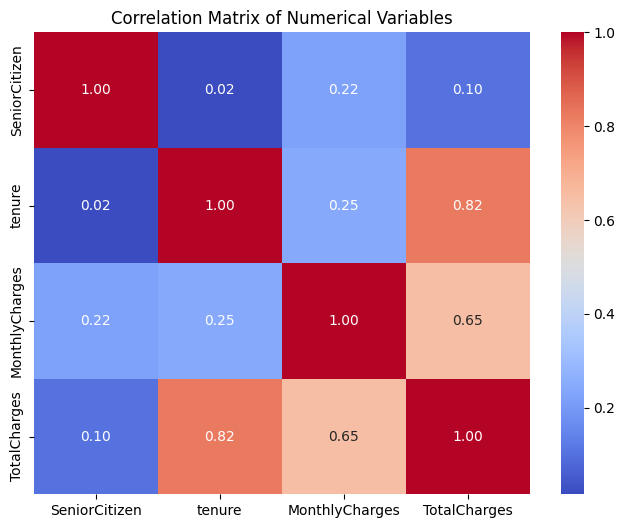

In [34]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

correlation_matrix = df[numeric_columns].corr()

display(correlation_matrix.round(2))

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

# **Feature Preparation & Encoding**

## **Check the Current Dataset**

In [35]:
print("Dataset shape:", df.shape)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate records:")
print(df.duplicated().sum())

Dataset shape: (7021, 20)

Data types:


,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object



Missing values:
0

Duplicate records:
0


## **Convert Target Variable**

In [36]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Target variable after encoding:")
print(df["Churn"].value_counts())

Target variable after encoding:
Churn
0    5164
1    1857
Name: count, dtype: int64


In [37]:
print("\nTarget data type:")
print(df["Churn"].dtype)


Target data type:
int64


## **Separate Features and Target**

In [38]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature dataset shape: (7021, 19)
Target dataset shape: (7021,)


## **Check Categorical and Numerical Variables**

In [39]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


## **One-Hot Encoding**

In [40]:
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Original number of features:", X.shape[1])
print("Number of encoded features:", X_encoded.shape[1])

Original number of features: 19
Number of encoded features: 30


In [41]:
display(X_encoded.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0


In [42]:
print(X_encoded.dtypes.value_counts())

int64      28
float64     2
Name: count, dtype: int64


## **Check Final Feature Dataset**

In [43]:
print("Final feature matrix shape:", X_encoded.shape)

print("\nMissing values:")
print(X_encoded.isnull().sum().sum())

print("\nDuplicate rows:")
print(X_encoded.duplicated().sum())

Final feature matrix shape: (7021, 30)

Missing values:
0

Duplicate rows:
18


In [44]:
duplicate_feature_rows = X_encoded[
    X_encoded.duplicated(keep=False)
]

print("Number of duplicate feature rows:",
      len(duplicate_feature_rows))

print("\nChurn outcomes for these duplicated feature rows:")

duplicate_indices = duplicate_feature_rows.index

display(
    pd.DataFrame({
        "Churn": y.loc[duplicate_indices]
    }).value_counts()
)

Number of duplicate feature rows: 36

Churn outcomes for these duplicated feature rows:


,count
Churn,
0,18
1,18


In [45]:
duplicate_check = pd.DataFrame({
    "Feature_Duplicate": X_encoded.duplicated(keep=False),
    "Churn": y
})

display(
    duplicate_check[
        duplicate_check["Feature_Duplicate"] == True
    ].sort_index()
)

,Feature_Duplicate,Churn
100,True,0
128,True,0
295,True,0
684,True,0
710,True,1
772,True,1
975,True,1
1048,True,1
1733,True,1
1933,True,0


# **Train/Test Split**

## **Split the Dataset**

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (5616, 30)
Testing feature shape: (1405, 30)

Training target shape: (5616,)
Testing target shape: (1405,)


## **Check Class Distribution**

In [47]:
print("Original dataset:")
display(
    y.value_counts(normalize=True).mul(100).round(2)
)

print("\nTraining dataset:")
display(
    y_train.value_counts(normalize=True).mul(100).round(2)
)

print("\nTesting dataset:")
display(
    y_test.value_counts(normalize=True).mul(100).round(2)
)

Original dataset:


,proportion
Churn,
0,73.55
1,26.45



Training dataset:


,proportion
Churn,
0,73.56
1,26.44



Testing dataset:


,proportion
Churn,
0,73.52
1,26.48


## **Feature Scaling**

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


# **Machine Learning Models**

## **Logistic Regression**

In [49]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test_scaled
)

logistic_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print("Logistic Regression training completed.")
print("Number of predictions:", len(logistic_predictions))

Logistic Regression training completed.
Number of predictions: 1405


## **Decision Tree**

In [50]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

dt_predictions = decision_tree.predict(
    X_test
)

dt_probabilities = decision_tree.predict_proba(
    X_test
)[:, 1]

print("Decision Tree training completed.")
print("Number of predictions:", len(dt_predictions))

Decision Tree training completed.
Number of predictions: 1405


## **Random Forest**

In [51]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(
    X_train,
    y_train
)

rf_predictions = random_forest.predict(
    X_test
)

rf_probabilities = random_forest.predict_proba(
    X_test
)[:, 1]

print("Random Forest training completed.")
print("Number of predictions:", len(rf_predictions))

Random Forest training completed.
Number of predictions: 1405


## **Gradient Boosting**

In [52]:
gradient_boosting = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting.fit(
    X_train,
    y_train
)

gb_predictions = gradient_boosting.predict(
    X_test
)

gb_probabilities = gradient_boosting.predict_proba(
    X_test
)[:, 1]

print("Gradient Boosting training completed.")
print("Number of predictions:", len(gb_predictions))

Gradient Boosting training completed.
Number of predictions: 1405


## **Basic Model Check**

In [53]:
print("Logistic Regression predictions:",
      len(logistic_predictions))

print("Decision Tree predictions:",
      len(dt_predictions))

print("Random Forest predictions:",
      len(rf_predictions))

print("Gradient Boosting predictions:",
      len(gb_predictions))

Logistic Regression predictions: 1405
Decision Tree predictions: 1405
Random Forest predictions: 1405
Gradient Boosting predictions: 1405


# **Model Evaluation and Comparison**

## **Create Evaluation Function**

In [54]:
def evaluate_model(model_name, y_true, predictions, probabilities):

    accuracy = accuracy_score(y_true, predictions)

    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        probabilities
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

print("Evaluation function created successfully.")

Evaluation function created successfully.


## **Evaluate All Four Models**

In [55]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_predictions,
        dt_probabilities
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probabilities
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_predictions,
        gb_probabilities
    )
)

results_df = pd.DataFrame(results)

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8028,0.6599,0.5269,0.5859,0.8403
1,Decision Tree,0.7865,0.6452,0.4301,0.5161,0.8212
2,Random Forest,0.7772,0.6122,0.4328,0.5071,0.8194
3,Gradient Boosting,0.8028,0.6715,0.5000,0.5732,0.8386


## **Convert Scores to Percentages**

In [56]:
percentage_results = results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

percentage_results[metric_columns] = (
    percentage_results[metric_columns] * 100
)

display(
    percentage_results.round(2)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,80.28,65.99,52.69,58.59,84.03
1,Decision Tree,78.65,64.52,43.01,51.61,82.12
2,Random Forest,77.72,61.22,43.28,50.71,81.94
3,Gradient Boosting,80.28,67.15,50.00,57.32,83.86


## **Identify the Best Model**

In [57]:
model_ranking = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("Models ranked by F1-Score:")

display(
    model_ranking.round(4)
)

Models ranked by F1-Score:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8028,0.6599,0.5269,0.5859,0.8403
1,Gradient Boosting,0.8028,0.6715,0.5000,0.5732,0.8386
2,Decision Tree,0.7865,0.6452,0.4301,0.5161,0.8212
3,Random Forest,0.7772,0.6122,0.4328,0.5071,0.8194


## **Model Performance Visualisation**

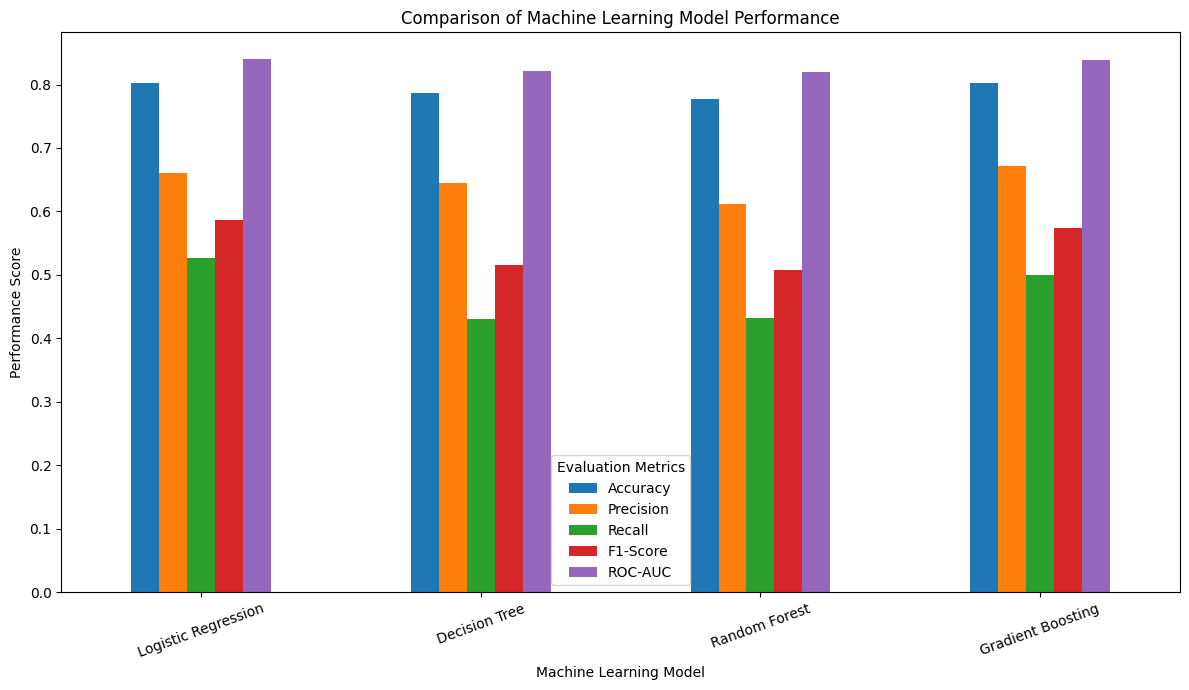

In [58]:
plot_data = results_df.set_index("Model")[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

plot_data.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Comparison of Machine Learning Model Performance")
plt.xlabel("Machine Learning Model")
plt.ylabel("Performance Score")

plt.xticks(rotation=20)

plt.legend(
    title="Evaluation Metrics"
)

plt.tight_layout()
plt.show()

## **Confusion Matrices**

### Logistic Regression

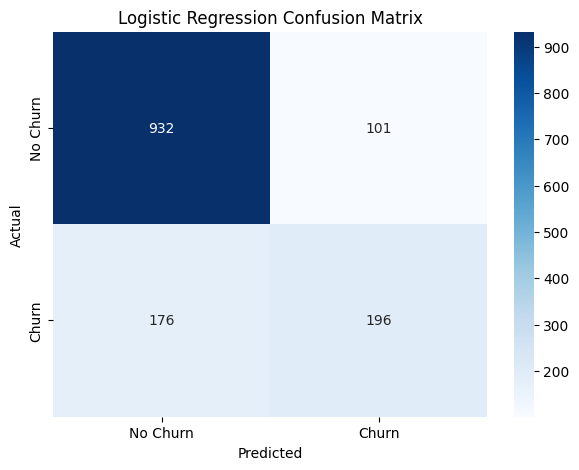

In [59]:
cm_lr = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Decision Tree

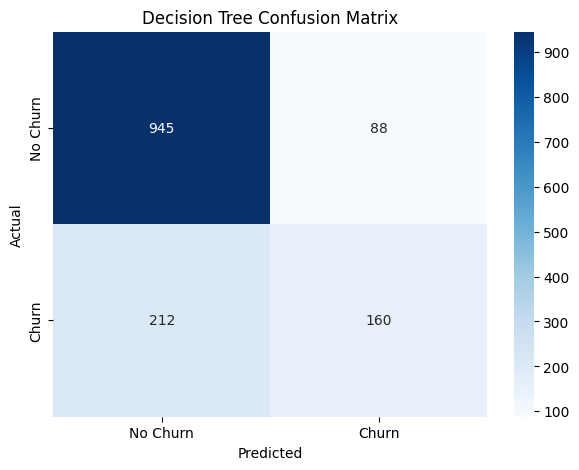

In [60]:
cm_dt = confusion_matrix(
    y_test,
    dt_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Random Forest

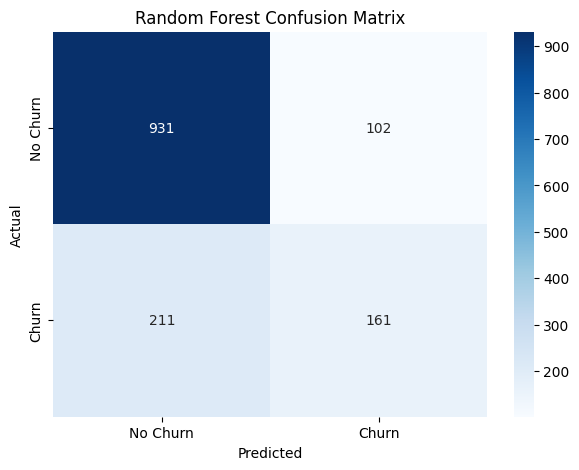

In [61]:
cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Gradient Boosting

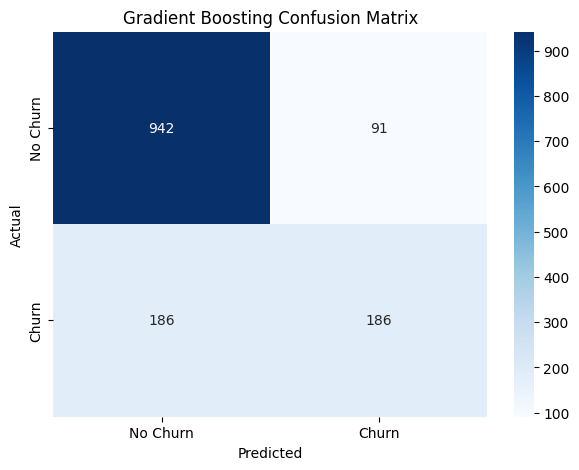

In [62]:
cm_gb = confusion_matrix(
    y_test,
    gb_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## **ROC Curve Comparison**

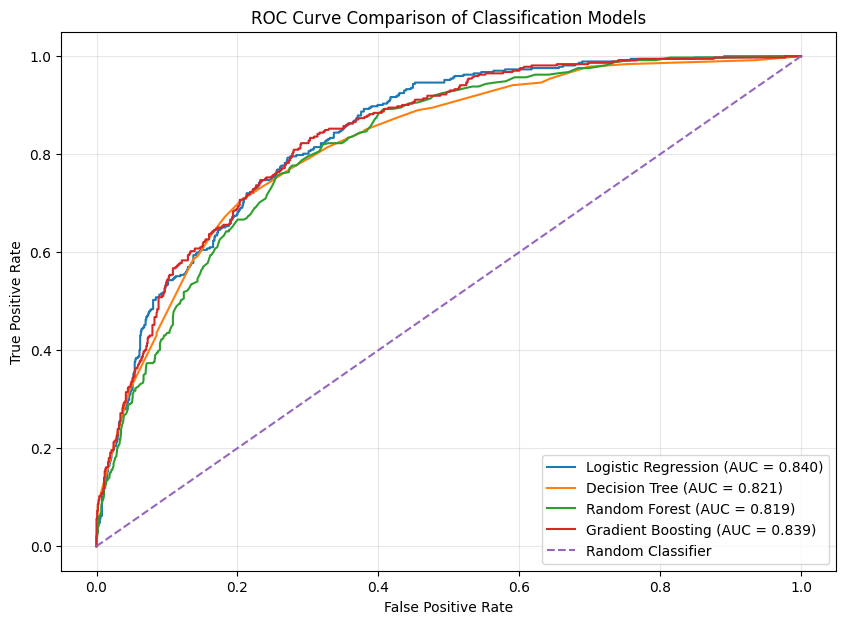

In [63]:
model_probabilities = {
    "Logistic Regression": logistic_probabilities,
    "Decision Tree": dt_probabilities,
    "Random Forest": rf_probabilities,
    "Gradient Boosting": gb_probabilities
}

plt.figure(figsize=(10, 7))

for model_name, probabilities in model_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison of Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# **Improve the models**

## **Tune Logistic Regression**

In [64]:
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    param_grid=lr_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

lr_grid.fit(
    X_train_scaled,
    y_train
)

print("Best Logistic Regression parameters:")
print(lr_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(round(lr_grid.best_score_, 4))

Best Logistic Regression parameters:
{'C': 0.1, 'class_weight': 'balanced', 'solver': 'lbfgs'}

Best cross-validation F1-score:
0.6315


## **Evaluate Tuned Logistic Regression**

In [65]:
best_lr = lr_grid.best_estimator_

best_lr_predictions = best_lr.predict(
    X_test_scaled
)

best_lr_probabilities = best_lr.predict_proba(
    X_test_scaled
)[:, 1]

tuned_lr_results = evaluate_model(
    "Tuned Logistic Regression",
    y_test,
    best_lr_predictions,
    best_lr_probabilities
)

display(
    pd.DataFrame([tuned_lr_results]).round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Logistic Regression,0.7409,0.5071,0.7688,0.6111,0.8392


## **Tune Gradient Boosting**

In [67]:
gb_param_grid = {
    "n_estimators": [100, 150],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_split": [2, 5]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(
        random_state=42
    ),
    param_grid=gb_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

gb_grid.fit(
    X_train,
    y_train
)

print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(round(gb_grid.best_score_, 4))

Best Gradient Boosting parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}

Best cross-validation F1-score:
0.5849


## **evaluate the tuned model**

In [68]:
best_gb = gb_grid.best_estimator_

best_gb_predictions = best_gb.predict(X_test)

best_gb_probabilities = best_gb.predict_proba(X_test)[:, 1]

tuned_gb_results = evaluate_model(
    "Tuned Gradient Boosting",
    y_test,
    best_gb_predictions,
    best_gb_probabilities
)

display(
    pd.DataFrame([tuned_gb_results]).round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Gradient Boosting,0.805,0.675,0.5081,0.5798,0.8391


In [69]:
final_model_comparison = pd.concat(
    [
        results_df,
        pd.DataFrame([tuned_lr_results]),
        pd.DataFrame([tuned_gb_results])
    ],
    ignore_index=True
)

display(
    final_model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8028,0.6599,0.5269,0.5859,0.8403
1,Decision Tree,0.7865,0.6452,0.4301,0.5161,0.8212
2,Random Forest,0.7772,0.6122,0.4328,0.5071,0.8194
3,Gradient Boosting,0.8028,0.6715,0.5000,0.5732,0.8386
4,Tuned Logistic Regression,0.7409,0.5071,0.7688,0.6111,0.8392
5,Tuned Gradient Boosting,0.8050,0.6750,0.5081,0.5798,0.8391


# **Final Model Analysis**

## **Final Confusion Matrix**

Confusion Matrix:
[[755 278]
 [ 86 286]]


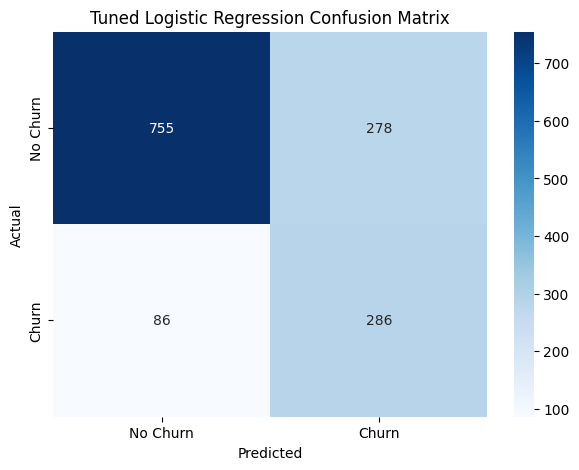

In [70]:
final_cm = confusion_matrix(
    y_test,
    best_lr_predictions
)

print("Confusion Matrix:")
print(final_cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Tuned Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## **Classification Report**

In [71]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        best_lr_predictions,
        target_names=["No Churn", "Churn"],
        digits=4
    )
)

              precision    recall  f1-score   support

    No Churn     0.8977    0.7309    0.8058      1033
       Churn     0.5071    0.7688    0.6111       372

    accuracy                         0.7409      1405
   macro avg     0.7024    0.7498    0.7084      1405
weighted avg     0.7943    0.7409    0.7542      1405



## **Final ROC Curve**

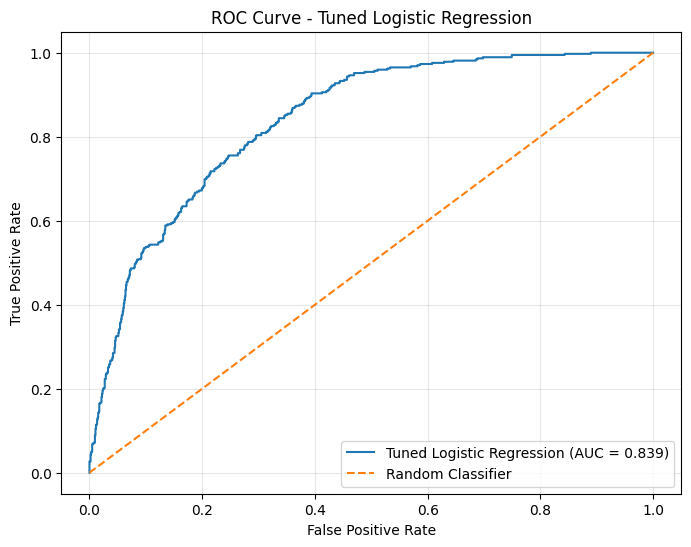

Final ROC-AUC: 0.8392


In [72]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    best_lr_probabilities
)

final_auc = roc_auc_score(
    y_test,
    best_lr_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Tuned Logistic Regression (AUC = {final_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Tuned Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("Final ROC-AUC:", round(final_auc, 4))

## **Feature Importance Using Logistic Regression Coefficients**

In [73]:
feature_coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": best_lr.coef_[0]
})

feature_coefficients["Absolute_Coefficient"] = (
    feature_coefficients["Coefficient"].abs()
)

feature_coefficients = feature_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

display(
    feature_coefficients.head(15).round(4)
)

,Feature,Coefficient,Absolute_Coefficient
1,tenure,-1.0596,1.0596
25,Contract_Two year,-0.6026,0.6026
10,InternetService_Fiber optic,0.4160,0.4160
3,TotalCharges,0.3694,0.3694
24,Contract_One year,-0.2862,0.2862
28,PaymentMethod_Electronic check,0.1599,0.1599
13,OnlineSecurity_Yes,-0.1557,0.1557
26,PaperlessBilling_Yes,0.1532,0.1532
19,TechSupport_Yes,-0.1240,0.1240
9,MultipleLines_Yes,0.1210,0.1210


In [74]:
positive_features = feature_coefficients[
    feature_coefficients["Coefficient"] > 0
].sort_values(
    by="Coefficient",
    ascending=False
)

print("Features associated with higher churn tendency:")

display(
    positive_features.head(10).round(4)
)

Features associated with higher churn tendency:


,Feature,Coefficient,Absolute_Coefficient
10,InternetService_Fiber optic,0.4160,0.4160
3,TotalCharges,0.3694,0.3694
28,PaymentMethod_Electronic check,0.1599,0.1599
26,PaperlessBilling_Yes,0.1532,0.1532
9,MultipleLines_Yes,0.1210,0.1210
23,StreamingMovies_Yes,0.1125,0.1125
21,StreamingTV_Yes,0.0963,0.0963
0,SeniorCitizen,0.0895,0.0895
8,MultipleLines_No phone service,0.0859,0.0859
2,MonthlyCharges,0.0171,0.0171


In [75]:
negative_features = feature_coefficients[
    feature_coefficients["Coefficient"] < 0
].sort_values(
    by="Coefficient",
    ascending=True
)

print("Features associated with lower churn tendency:")

display(
    negative_features.head(10).round(4)
)

Features associated with lower churn tendency:


,Feature,Coefficient,Absolute_Coefficient
1,tenure,-1.0596,1.0596
25,Contract_Two year,-0.6026,0.6026
24,Contract_One year,-0.2862,0.2862
13,OnlineSecurity_Yes,-0.1557,0.1557
19,TechSupport_Yes,-0.1240,0.1240
7,PhoneService_Yes,-0.0859,0.0859
6,Dependents_Yes,-0.0843,0.0843
15,OnlineBackup_Yes,-0.0535,0.0535
14,OnlineBackup_No internet service,-0.0456,0.0456
11,InternetService_No,-0.0456,0.0456


## **Plot the Most Important Features**

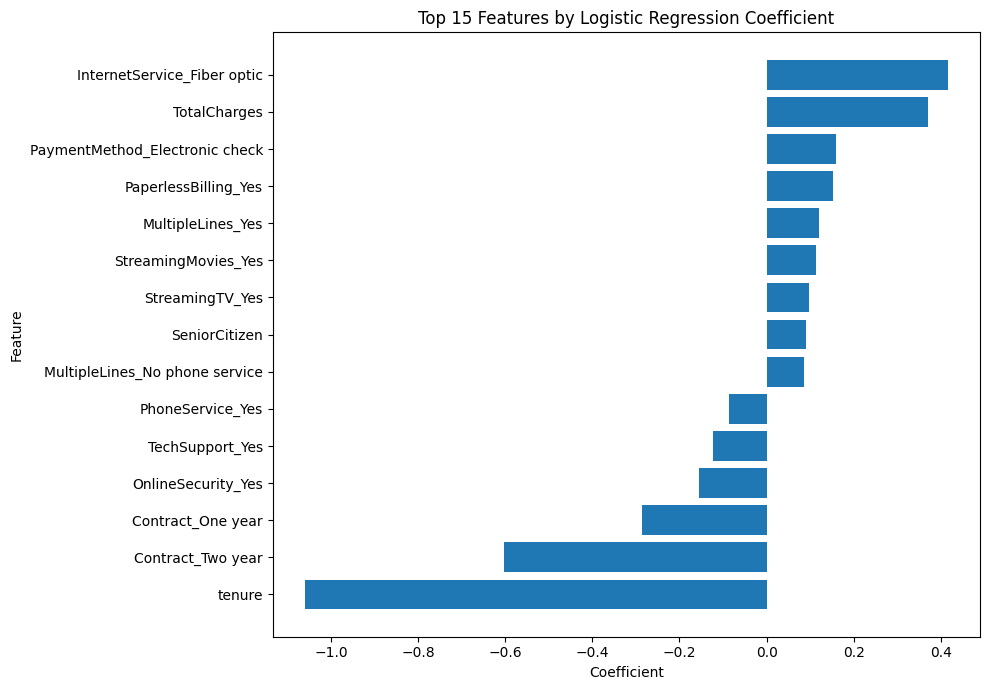

In [76]:
top_features = feature_coefficients.head(15).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title(
    "Top 15 Features by Logistic Regression Coefficient"
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# **Churn Prediction / Risk Segmentation**

## **Generate Churn Probabilities**

In [77]:
# Probability of Churn = 1
churn_probability = best_lr.predict_proba(X_test_scaled)[:, 1]

# Predicted churn class
churn_prediction = best_lr.predict(X_test_scaled)

# Create prediction dataframe
churn_prediction_df = pd.DataFrame({
    "Actual_Churn": y_test.values,
    "Predicted_Churn": churn_prediction,
    "Churn_Probability": churn_probability
})

print("Churn prediction completed.")
print("Number of customers analysed:", len(churn_prediction_df))

display(
    churn_prediction_df.head(10).round(4)
)

Churn prediction completed.
Number of customers analysed: 1405


,Actual_Churn,Predicted_Churn,Churn_Probability
0,0,1,0.8871
1,1,1,0.8205
2,1,1,0.5102
3,0,0,0.1425
4,0,0,0.0327
5,0,1,0.5632
6,0,0,0.3238
7,1,1,0.9079
8,0,0,0.0536
9,0,0,0.0454


## **Create Risk Categories**

In [78]:
def assign_risk(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"


churn_prediction_df["Risk_Category"] = (
    churn_prediction_df["Churn_Probability"]
    .apply(assign_risk)
)

print("Risk segmentation completed.")

display(
    churn_prediction_df.head(10).round(4)
)

Risk segmentation completed.


,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Category
0,0,1,0.8871,High Risk
1,1,1,0.8205,High Risk
2,1,1,0.5102,Medium Risk
3,0,0,0.1425,Low Risk
4,0,0,0.0327,Low Risk
5,0,1,0.5632,Medium Risk
6,0,0,0.3238,Medium Risk
7,1,1,0.9079,High Risk
8,0,0,0.0536,Low Risk
9,0,0,0.0454,Low Risk


## **Risk Category Distribution**

In [79]:
risk_distribution = (
    churn_prediction_df["Risk_Category"]
    .value_counts()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    .fillna(0)
    .astype(int)
)

risk_percentage = (
    risk_distribution /
    len(churn_prediction_df) * 100
)

risk_summary = pd.DataFrame({
    "Customer_Count": risk_distribution,
    "Percentage": risk_percentage
})

display(
    risk_summary.round(2)
)

,Customer_Count,Percentage
Risk_Category,,
Low Risk,581,41.35
Medium Risk,367,26.12
High Risk,457,32.53


## **Visualise Risk Segmentation**

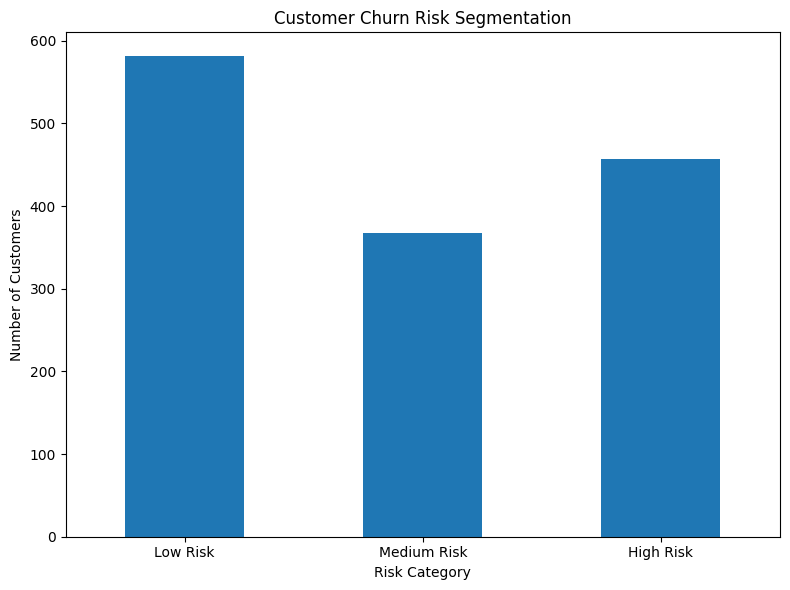

In [80]:
plt.figure(figsize=(8, 6))

risk_distribution.plot(
    kind="bar"
)

plt.title("Customer Churn Risk Segmentation")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **Probability Distribution**

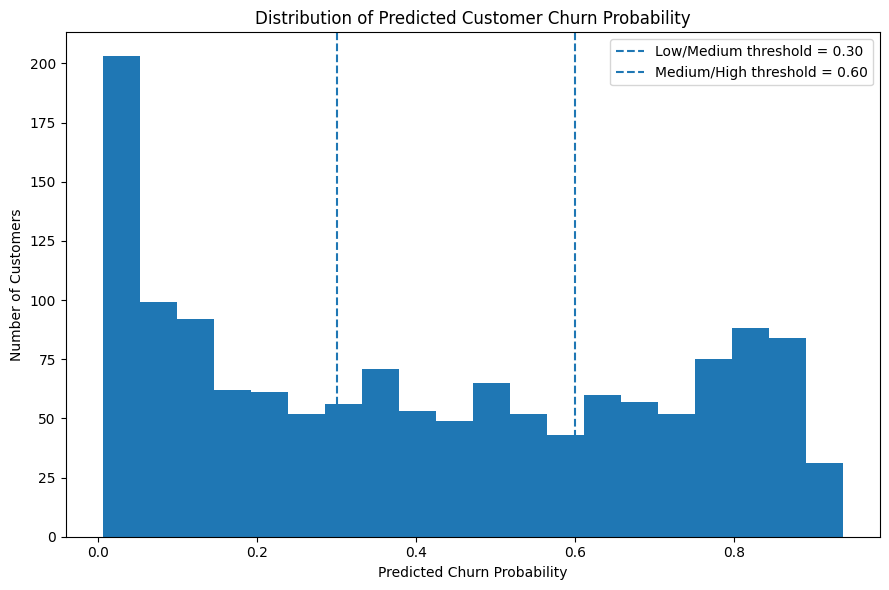

In [81]:
plt.figure(figsize=(9, 6))

plt.hist(
    churn_prediction_df["Churn_Probability"],
    bins=20
)

plt.axvline(
    0.30,
    linestyle="--",
    label="Low/Medium threshold = 0.30"
)

plt.axvline(
    0.60,
    linestyle="--",
    label="Medium/High threshold = 0.60"
)

plt.title("Distribution of Predicted Customer Churn Probability")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")

plt.legend()
plt.tight_layout()
plt.show()

## **Actual Churn Within Each Risk Group**

In [82]:
risk_actual_churn = pd.crosstab(
    churn_prediction_df["Risk_Category"],
    churn_prediction_df["Actual_Churn"],
    normalize="index"
) * 100

risk_actual_churn = risk_actual_churn.rename(
    columns={
        0: "Actual No Churn (%)",
        1: "Actual Churn (%)"
    }
)

risk_actual_churn = risk_actual_churn.reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
)

display(
    risk_actual_churn.round(2)
)

Actual_Churn,Actual No Churn (%),Actual Churn (%)
Risk_Category,,
Low Risk,96.39,3.61
Medium Risk,72.75,27.25
High Risk,45.08,54.92


## **Visualise Actual Churn by Risk**

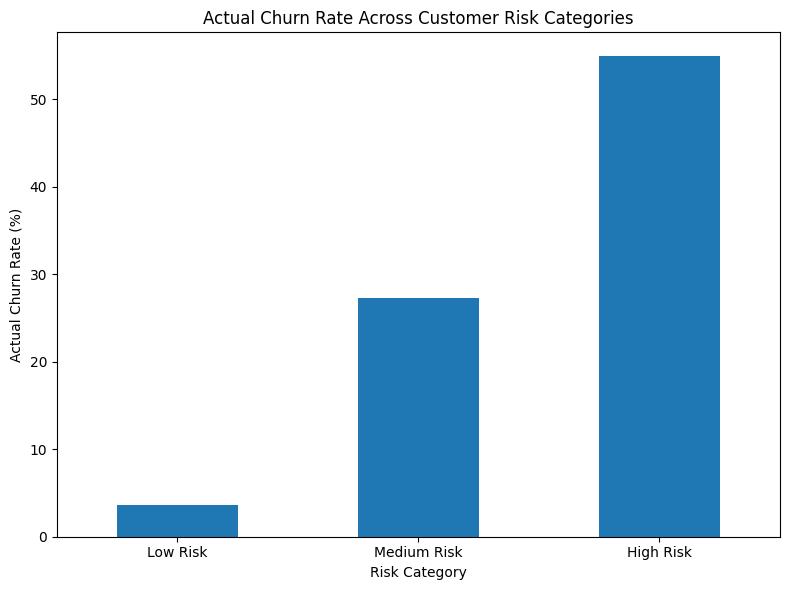

,Actual Churn Rate (%)
Risk_Category,
Low Risk,3.61
Medium Risk,27.25
High Risk,54.92


In [83]:
actual_churn_rate = (
    churn_prediction_df
    .groupby("Risk_Category")["Actual_Churn"]
    .mean()
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
    * 100
)

plt.figure(figsize=(8, 6))

actual_churn_rate.plot(
    kind="bar"
)

plt.title("Actual Churn Rate Across Customer Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Actual Churn Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(
    actual_churn_rate.round(2).to_frame(
        "Actual Churn Rate (%)"
    )
)

## **Create Retention Priority**

In [84]:
def retention_priority(risk):
    if risk == "High Risk":
        return "Immediate"
    elif risk == "Medium Risk":
        return "Monitor"
    else:
        return "Maintain"


churn_prediction_df["Retention_Priority"] = (
    churn_prediction_df["Risk_Category"]
    .apply(retention_priority)
)

display(
    churn_prediction_df.head(15).round(4)
)

,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Category,Retention_Priority
0,0,1,0.8871,High Risk,Immediate
1,1,1,0.8205,High Risk,Immediate
2,1,1,0.5102,Medium Risk,Monitor
3,0,0,0.1425,Low Risk,Maintain
4,0,0,0.0327,Low Risk,Maintain
5,0,1,0.5632,Medium Risk,Monitor
6,0,0,0.3238,Medium Risk,Monitor
7,1,1,0.9079,High Risk,Immediate
8,0,0,0.0536,Low Risk,Maintain
9,0,0,0.0454,Low Risk,Maintain


## **Risk Summary**

In [85]:
final_risk_summary = (
    churn_prediction_df
    .groupby("Risk_Category")
    .agg(
        Customers=("Risk_Category", "size"),
        Average_Churn_Probability=("Churn_Probability", "mean"),
        Actual_Churn_Rate=("Actual_Churn", "mean")
    )
    .reindex(["Low Risk", "Medium Risk", "High Risk"])
)

final_risk_summary["Customer_Percentage"] = (
    final_risk_summary["Customers"]
    / len(churn_prediction_df)
    * 100
)

final_risk_summary["Actual_Churn_Rate"] = (
    final_risk_summary["Actual_Churn_Rate"] * 100
)

display(
    final_risk_summary.round(2)
)

,Customers,Average_Churn_Probability,Actual_Churn_Rate,Customer_Percentage
Risk_Category,,,,
Low Risk,581,0.11,3.61,41.35
Medium Risk,367,0.44,27.25,26.12
High Risk,457,0.77,54.92,32.53
